In [ ]:
#Clasificación de imágenes del MINST usando una red de una capa y una red multicapas

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import random

In [5]:
# Cargamos la imagenes del conjunto de entrenamiento
cats_train = []
dogs_train = []
for i in range(3000):
    img = Image.open('/Users/juda/lab_alma/ML_introduction/archive/training_set/cats/cat.'+ str(1+i)+'.jpg')
    cats_train.append(img.resize((64, 64)))
    img = Image.open('/Users/juda/lab_alma/ML_introduction/archive/training_set/dogs/dog.'+ str(1+i)+'.jpg')
    dogs_train.append(img.resize((64, 64)))
#Cargamos las imagenes del conjunto de prueba
cats_test = []
dogs_test = []
for i in range(1000):
    img = Image.open('/Users/juda/lab_alma/ML_introduction/archive/test_set/cats/cat.'+ str(4001+i)+'.jpg')
    cats_test.append(img.resize((64, 64)))
    img = Image.open('/Users/juda/lab_alma/ML_introduction/archive/test_set/dogs/dog.'+ str(4001+i)+'.jpg')
    dogs_test.append(img.resize((64, 64)))

#Mezclamos y acomodamos los datos de entrenamiento en forma de matriz, ademas de normalizar los datos
datos = [(x, 1) for x in cats_train] + [(x, 0) for x in dogs_train]

# Mezclar
random.shuffle(datos)

# Separar nuevamente
X_train = [x for x, origen in datos]
Y_train = [origen for x, origen in datos]

Y_train = np.array(Y_train)
X_train_flat = np.array(X_train).reshape(len(Y_train),-1)/255
X_train = np.array(X_train)

#Mezclamos y acomodamos los datos de entrenamiento en forma de matriz, ademas de normalizar los datos
datos = [(x, 1) for x in cats_test] + [(x, 0) for x in dogs_test]

# Mezclar
random.shuffle(datos)

# Separar nuevamente
X_test = [x for x, origen in datos]
Y_test = [origen for x, origen in datos]

Y_test = np.array(Y_test)
X_test_flat = np.array(X_test).reshape(len(Y_test),-1)/255
X_test = np.array(X_test)

#Eliminamos estos que solo gastarian memoria
del dogs_train, cats_train
del dogs_test, cats_test

In [8]:
print(np.shape(X_train))
print(np.shape(Y_train))

print(np.shape(X_train_flat))

print(np.shape(X_test))
print(np.shape(Y_test))
print(np.shape(X_test_flat))

(6000, 64, 64, 3)
(6000,)
(6000, 12288)
(2000, 64, 64, 3)
(2000,)
(2000, 12288)


Imagenes de entrenamiento



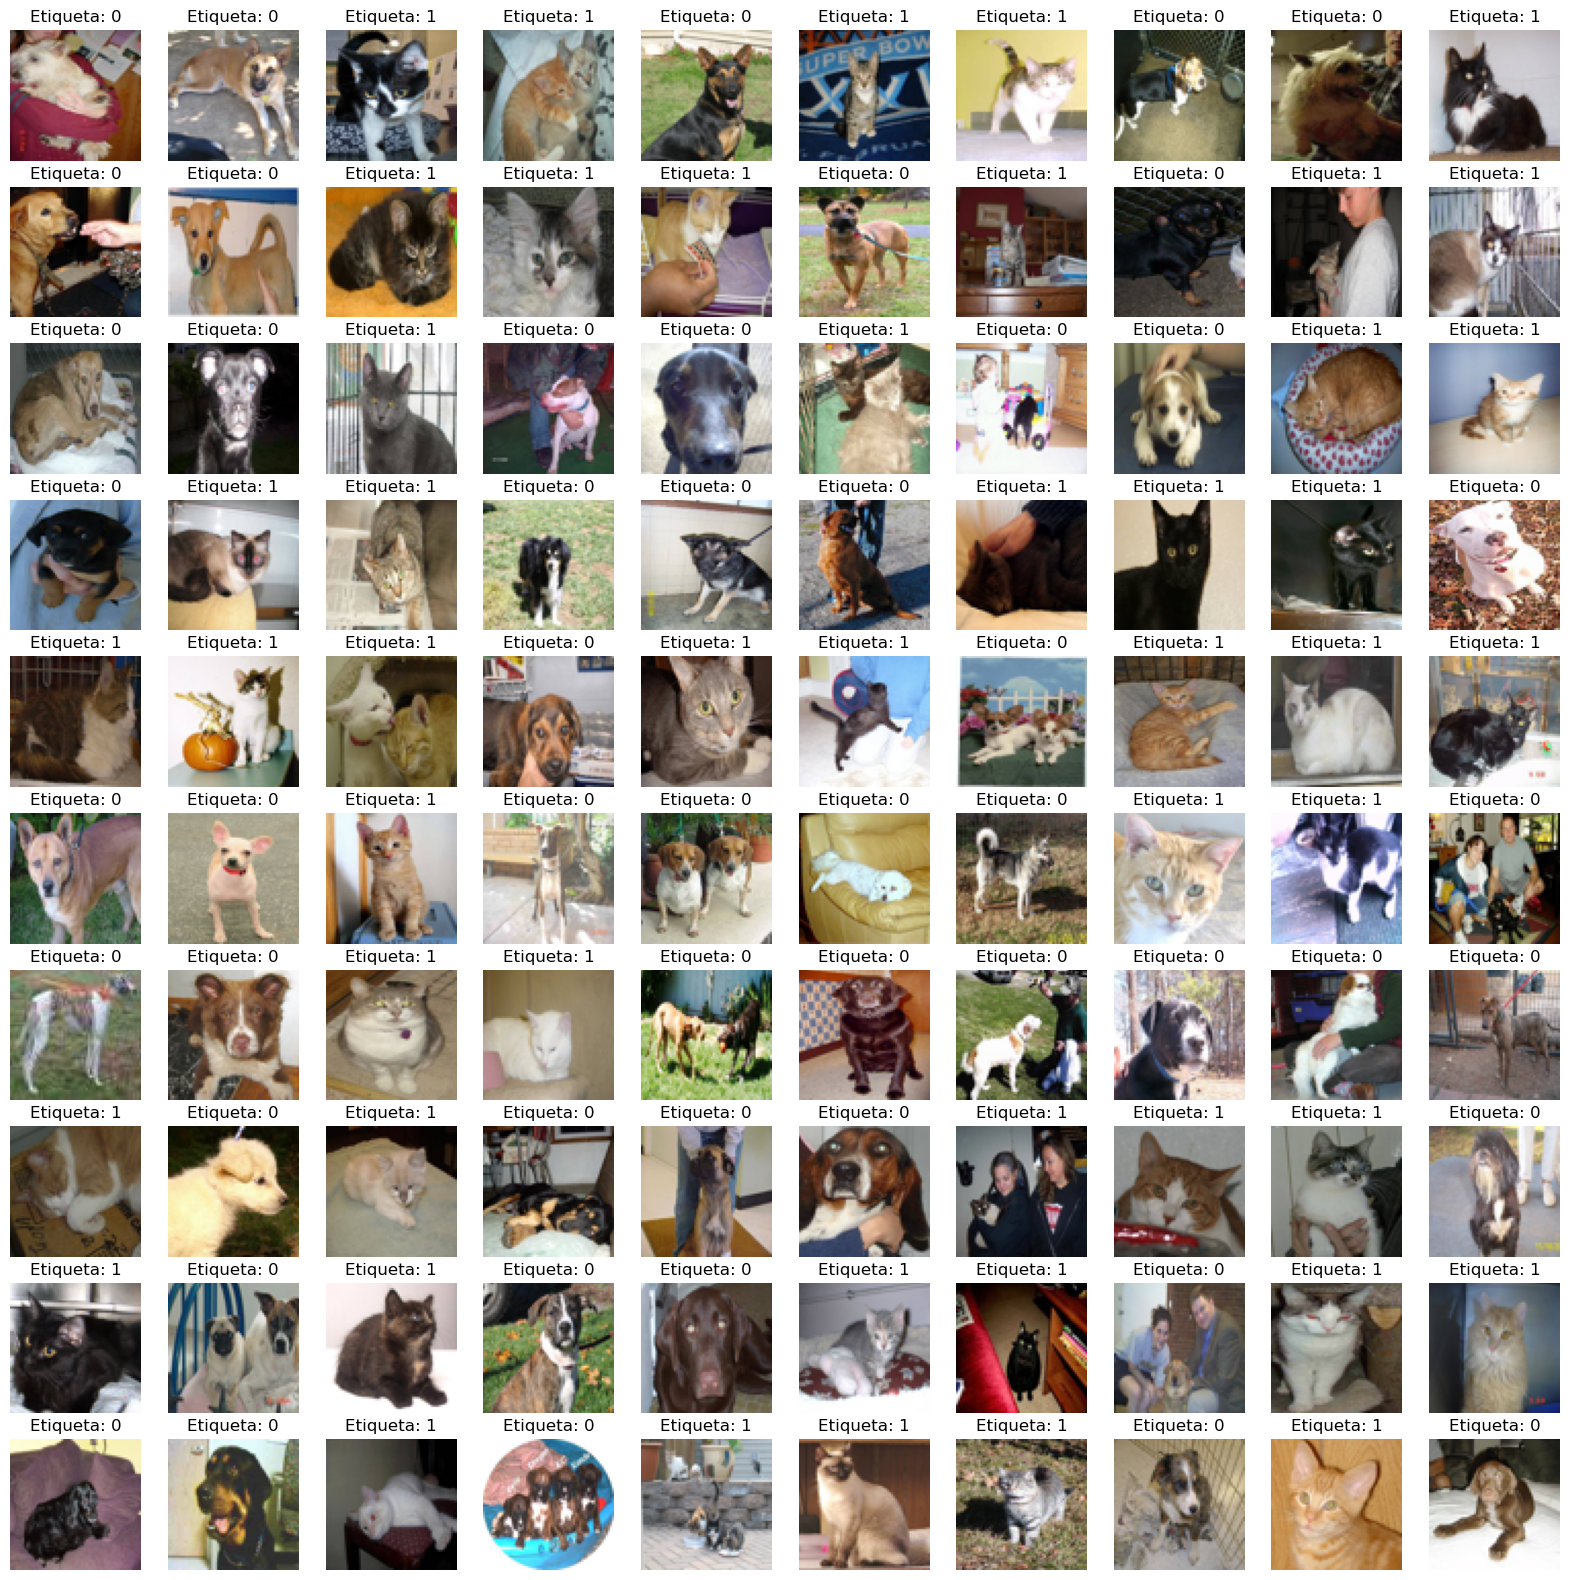

In [10]:
ncols = 10
nrows = 10

fig, axs = plt.subplots(figsize = (20, 20))
plt.axis('off')

print('Imagenes de entrenamiento\n')

for i in range(ncols * nrows):

  axs = fig.add_subplot(nrows, ncols, i + 1)
  axs.imshow(X_train[i], cmap = 'Blues')
  axs.axis('off')

  label = 'Etiqueta: ' + str(Y_train[i])
  plt.title(label)

plt.show()

In [11]:
model = tf.keras.Sequential([
    #tf.keras.layers.Dense(units=1, activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(units = 10, activation = 'softmax',input_shape=(12288,))])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                122890    
                                                                 
Total params: 122,890
Trainable params: 122,890
Non-trainable params: 0
_________________________________________________________________


2026-06-04 16:43:32.357224: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
tf.keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [13]:
model.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)

In [15]:
history = model.fit(
    X_train_flat,Y_train,
    epochs=20,
    validation_data=(X_test_flat,Y_test)
)

Epoch 1/20
188/188 [==============================] - 2s 6ms/step - loss: 5.9868 - accuracy: 0.5002 - val_loss: 4.1896 - val_accuracy: 0.5125
Epoch 2/20
188/188 [==============================] - 1s 4ms/step - loss: 5.3426 - accuracy: 0.5233 - val_loss: 6.7171 - val_accuracy: 0.5005
Epoch 3/20
188/188 [==============================] - 1s 4ms/step - loss: 5.1248 - accuracy: 0.5242 - val_loss: 6.3106 - val_accuracy: 0.5050
Epoch 4/20
188/188 [==============================] - 1s 4ms/step - loss: 5.0887 - accuracy: 0.5270 - val_loss: 6.6822 - val_accuracy: 0.5025
Epoch 5/20
188/188 [==============================] - 1s 4ms/step - loss: 5.2929 - accuracy: 0.5172 - val_loss: 6.7120 - val_accuracy: 0.5070
Epoch 6/20
188/188 [==============================] - 1s 4ms/step - loss: 5.0837 - accuracy: 0.5255 - val_loss: 6.4199 - val_accuracy: 0.5080
Epoch 7/20
188/188 [==============================] - 1s 4ms/step - loss: 4.7457 - accuracy: 0.5402 - val_loss: 11.2451 - val_accuracy: 0.5000
Epoch

Text(0.5, 1.0, 'LOSS')

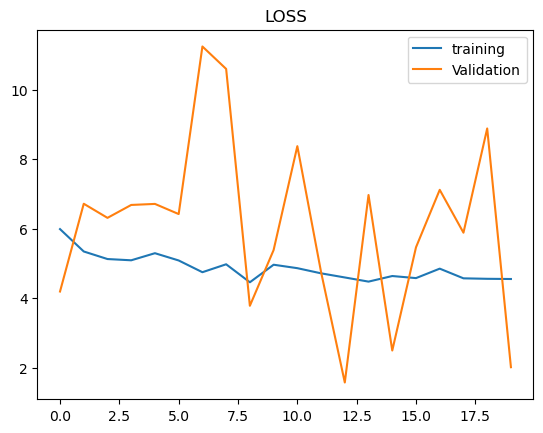

In [16]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [99]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=10, activation='linear',input_shape=(12288,)),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
model_2.summary()

model_2.compile(
    loss = 'binary_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_2)

Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_63 (Dense)            (None, 10)                122890    
                                                                 
 dense_64 (Dense)            (None, 1)                 11        
                                                                 
Total params: 122,901
Trainable params: 122,901
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [100]:
history_2 = model_2.fit(
    X_train_flat,Y_train,
    epochs=20,
    validation_data=(X_test_flat,Y_test)
)

Epoch 1/20
188/188 [==============================] - 2s 7ms/step - loss: 0.9009 - accuracy: 0.5248 - val_loss: 0.7166 - val_accuracy: 0.5115
Epoch 2/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6820 - accuracy: 0.5615 - val_loss: 0.6864 - val_accuracy: 0.5380
Epoch 3/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6750 - accuracy: 0.5770 - val_loss: 0.6719 - val_accuracy: 0.5750
Epoch 4/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6704 - accuracy: 0.5795 - val_loss: 0.6797 - val_accuracy: 0.5695
Epoch 5/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6674 - accuracy: 0.5918 - val_loss: 0.6682 - val_accuracy: 0.5835
Epoch 6/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6671 - accuracy: 0.5878 - val_loss: 0.6688 - val_accuracy: 0.5975
Epoch 7/20
188/188 [==============================] - 1s 5ms/step - loss: 0.6634 - accuracy: 0.5968 - val_loss: 0.6697 - val_accuracy: 0.5965
Epoch 

Text(0.5, 1.0, 'LOSS')

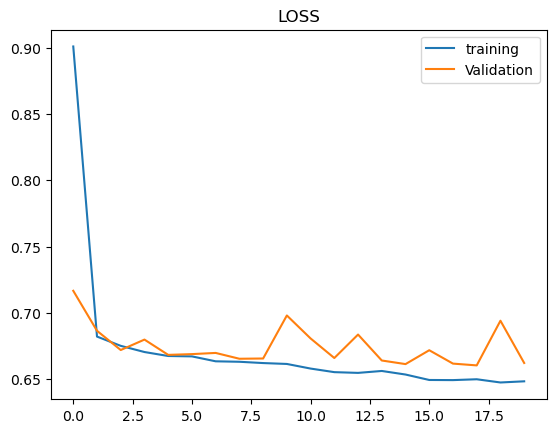

In [101]:
train_loss = history_2.history['loss']
val_loss = history_2.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [102]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=10, activation='relu',input_shape=(12288,)),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
model_3.summary()
model_3.compile(
    loss = 'binary_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_3)

Model: "sequential_32"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_65 (Dense)            (None, 10)                122890    
                                                                 
 dense_66 (Dense)            (None, 1)                 11        
                                                                 
Total params: 122,901
Trainable params: 122,901
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [103]:
history_3 = model_3.fit(
    X_train_flat,Y_train,
    epochs=30,
    validation_data=(X_test_flat,Y_test)
)

Epoch 1/30
188/188 [==============================] - 2s 10ms/step - loss: 0.6921 - accuracy: 0.5285 - val_loss: 0.6843 - val_accuracy: 0.5610
Epoch 2/30
188/188 [==============================] - 1s 5ms/step - loss: 0.6792 - accuracy: 0.5700 - val_loss: 0.6904 - val_accuracy: 0.5470
Epoch 3/30
188/188 [==============================] - 1s 5ms/step - loss: 0.6680 - accuracy: 0.5910 - val_loss: 0.6653 - val_accuracy: 0.5925
Epoch 4/30
188/188 [==============================] - 1s 5ms/step - loss: 0.6596 - accuracy: 0.6052 - val_loss: 0.6597 - val_accuracy: 0.6130
Epoch 5/30
188/188 [==============================] - 1s 5ms/step - loss: 0.6538 - accuracy: 0.6062 - val_loss: 0.6585 - val_accuracy: 0.6055
Epoch 6/30
188/188 [==============================] - 1s 4ms/step - loss: 0.6532 - accuracy: 0.6062 - val_loss: 0.6708 - val_accuracy: 0.5880
Epoch 7/30
188/188 [==============================] - 1s 4ms/step - loss: 0.6508 - accuracy: 0.6103 - val_loss: 0.6575 - val_accuracy: 0.6120
Epoch

Text(0.5, 1.0, 'LOSS')

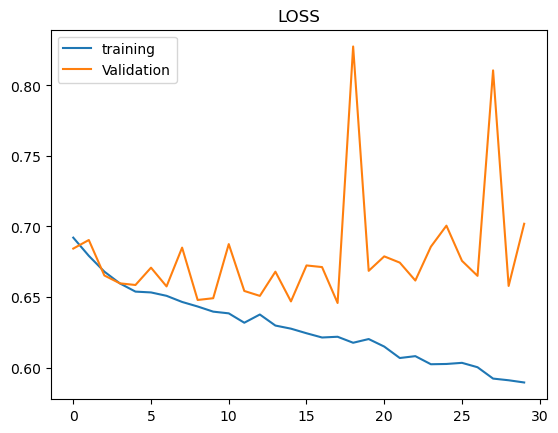

In [105]:
train_loss = history_3.history['loss']
val_loss = history_3.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [66]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=512, activation='relu',input_shape=(12288,)),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
model_5.summary()
model_5.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tf.keras.utils.plot_model(model_5)

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_32 (Dense)            (None, 512)               6291968   
                                                                 
 dense_33 (Dense)            (None, 512)               262656    
                                                                 
 dense_34 (Dense)            (None, 1)                 513       
                                                                 
Total params: 6,555,137
Trainable params: 6,555,137
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [67]:
history_5 = model_5.fit(
    X_train_flat,Y_train,
    batch_size =128,
    epochs=50,
    validation_data=(X_test_flat,Y_test)
)

Epoch 1/50
47/47 [==============================] - 4s 76ms/step - loss: 0.6946 - accuracy: 0.5338 - val_loss: 0.6768 - val_accuracy: 0.5700
Epoch 2/50
47/47 [==============================] - 3s 64ms/step - loss: 0.6720 - accuracy: 0.5865 - val_loss: 0.6769 - val_accuracy: 0.5765
Epoch 3/50
47/47 [==============================] - 3s 58ms/step - loss: 0.6608 - accuracy: 0.6002 - val_loss: 0.6608 - val_accuracy: 0.6070
Epoch 4/50
47/47 [==============================] - 3s 62ms/step - loss: 0.6591 - accuracy: 0.6025 - val_loss: 0.6755 - val_accuracy: 0.5715
Epoch 5/50
47/47 [==============================] - 3s 61ms/step - loss: 0.6630 - accuracy: 0.6038 - val_loss: 0.6532 - val_accuracy: 0.6240
Epoch 6/50
47/47 [==============================] - 3s 62ms/step - loss: 0.6486 - accuracy: 0.6192 - val_loss: 0.6608 - val_accuracy: 0.5925
Epoch 7/50
47/47 [==============================] - 3s 62ms/step - loss: 0.6425 - accuracy: 0.6240 - val_loss: 0.6626 - val_accuracy: 0.5945
Epoch 8/50
47

Text(0.5, 1.0, 'LOSS')

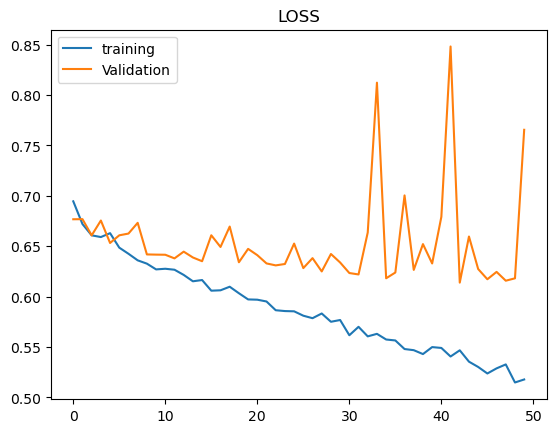

In [106]:
train_loss = history_5.history['loss']
val_loss = history_5.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [57]:
print(np.shape(X_train),np.shape(X_test))

(6000, 64, 64, 3) (2000, 64, 64, 3)


In [107]:
modelConv_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
modelConv_1.summary()
modelConv_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tf.keras.utils.plot_model(modelConv_1)

Model: "sequential_33"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_37 (Conv2D)          (None, 31, 31, 16)        448       
                                                                 
 flatten_23 (Flatten)        (None, 15376)             0         
                                                                 
 dense_67 (Dense)            (None, 512)               7873024   
                                                                 
 dense_68 (Dense)            (None, 1)                 513       
                                                                 
Total params: 7,873,985
Trainable params: 7,873,985
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [108]:
history_conv1 = modelConv_1.fit(
    X_train_esp,
    Y_train,
    batch_size=128,
    epochs=20,
    validation_data=(X_test_esp, Y_test)
)

Epoch 1/20
47/47 [==============================] - 7s 142ms/step - loss: 214.0819 - accuracy: 0.5255 - val_loss: 5.1155 - val_accuracy: 0.5570
Epoch 2/20
47/47 [==============================] - 6s 122ms/step - loss: 3.9989 - accuracy: 0.5737 - val_loss: 3.3942 - val_accuracy: 0.5570
Epoch 3/20
47/47 [==============================] - 6s 138ms/step - loss: 3.0753 - accuracy: 0.5858 - val_loss: 3.0524 - val_accuracy: 0.5735
Epoch 4/20
47/47 [==============================] - 6s 133ms/step - loss: 2.9510 - accuracy: 0.6112 - val_loss: 2.6275 - val_accuracy: 0.5675
Epoch 5/20
47/47 [==============================] - 7s 154ms/step - loss: 1.8689 - accuracy: 0.6518 - val_loss: 2.0766 - val_accuracy: 0.5485
Epoch 6/20
47/47 [==============================] - 7s 160ms/step - loss: 1.4990 - accuracy: 0.6758 - val_loss: 2.3098 - val_accuracy: 0.5510
Epoch 7/20
47/47 [==============================] - 7s 152ms/step - loss: 1.3386 - accuracy: 0.6898 - val_loss: 1.9546 - val_accuracy: 0.5790
Epoc

In [109]:
print(Y_train.shape)
print(np.unique(Y_train))

(6000,)
[0 1]


Text(0.5, 1.0, 'LOSS')

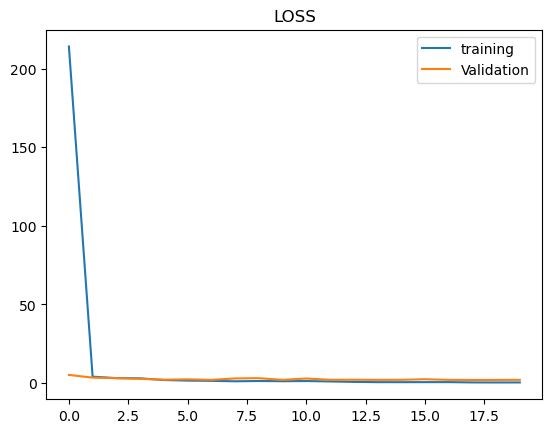

In [110]:
train_loss = history_conv1.history['loss']
val_loss = history_conv1.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")


In [120]:
modelConv_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(64,64,3)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2),padding='valid',activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 1, activation = 'sigmoid')])
modelConv_2.summary()
modelConv_2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tf.keras.utils.plot_model(modelConv_2)

Model: "sequential_36"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_43 (Conv2D)          (None, 31, 31, 16)        448       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 15, 15, 16)       0         
 2D)                                                             
                                                                 
 conv2d_44 (Conv2D)          (None, 7, 7, 32)          4640      
                                                                 
 flatten_26 (Flatten)        (None, 1568)              0         
                                                                 
 dense_73 (Dense)            (None, 512)               803328    
                                                                 
 dense_74 (Dense)            (None, 1)                 513       
                                                     

In [121]:
history_conv2 = modelConv_2 .fit(
    X_train,Y_train,
    batch_size =128,
    epochs=6,
    validation_data=(X_test,Y_test)
)

Epoch 1/6
47/47 [==============================] - 4s 66ms/step - loss: 10.6887 - accuracy: 0.5403 - val_loss: 0.7377 - val_accuracy: 0.5775
Epoch 2/6
47/47 [==============================] - 3s 57ms/step - loss: 0.6418 - accuracy: 0.6342 - val_loss: 0.7290 - val_accuracy: 0.6090
Epoch 3/6
47/47 [==============================] - 3s 57ms/step - loss: 0.5077 - accuracy: 0.7377 - val_loss: 0.7415 - val_accuracy: 0.6200
Epoch 4/6
47/47 [==============================] - 3s 57ms/step - loss: 0.3878 - accuracy: 0.8187 - val_loss: 0.7693 - val_accuracy: 0.6190
Epoch 5/6
47/47 [==============================] - 3s 63ms/step - loss: 0.2835 - accuracy: 0.8807 - val_loss: 0.8266 - val_accuracy: 0.6260
Epoch 6/6
47/47 [==============================] - 3s 62ms/step - loss: 0.2035 - accuracy: 0.9215 - val_loss: 0.8763 - val_accuracy: 0.6330


Text(0.5, 1.0, 'LOSS')

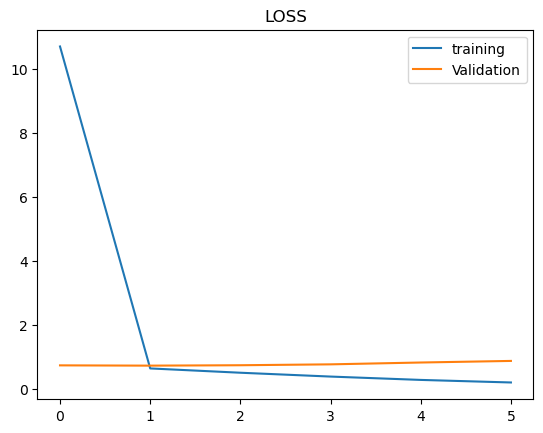

In [122]:
train_loss = history_conv2.history['loss']
val_loss = history_conv2.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [117]:
modelConv_3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(64,64,3)),
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2),padding='valid',activation='relu'),
    tf.keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),padding='valid',activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units=1, activation = 'sigmoid')])
modelConv_3.summary()
modelConv_3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
tf.keras.utils.plot_model(modelConv_3)

Model: "sequential_35"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_40 (Conv2D)          (None, 31, 31, 16)        448       
                                                                 
 conv2d_41 (Conv2D)          (None, 15, 15, 32)        4640      
                                                                 
 conv2d_42 (Conv2D)          (None, 7, 7, 64)          18496     
                                                                 
 flatten_25 (Flatten)        (None, 3136)              0         
                                                                 
 dense_71 (Dense)            (None, 512)               1606144   
                                                                 
 dense_72 (Dense)            (None, 1)                 513       
                                                                 
Total params: 1,630,241
Trainable params: 1,630,241
N

In [118]:
history_conv3 = modelConv_3 .fit(
    X_train,Y_train,
    batch_size =128,
    epochs=4,
    validation_data=(X_test,Y_test)
)

Epoch 1/4
47/47 [==============================] - 6s 107ms/step - loss: 5.4814 - accuracy: 0.5192 - val_loss: 0.6851 - val_accuracy: 0.5275
Epoch 2/4
47/47 [==============================] - 5s 100ms/step - loss: 0.6555 - accuracy: 0.5932 - val_loss: 0.6884 - val_accuracy: 0.5855
Epoch 3/4
47/47 [==============================] - 5s 104ms/step - loss: 0.5937 - accuracy: 0.6660 - val_loss: 0.6752 - val_accuracy: 0.5975
Epoch 4/4
47/47 [==============================] - 5s 112ms/step - loss: 0.4950 - accuracy: 0.7478 - val_loss: 0.7089 - val_accuracy: 0.6105


Text(0.5, 1.0, 'LOSS')

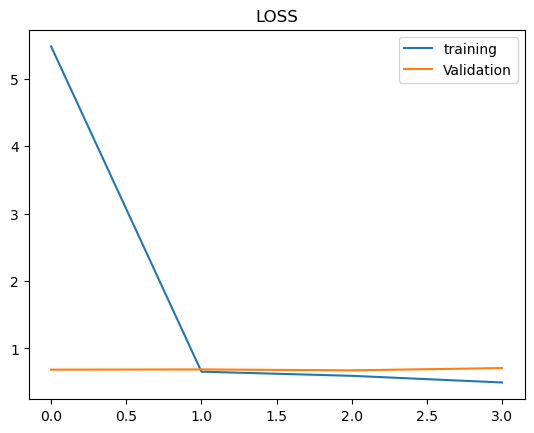

In [119]:
train_loss = history_conv3.history['loss']
val_loss = history_conv3.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")